# Process Mining Analysis of Research Agent

This notebook uses Process Mining through the pm4py tool to mine the flow of the research agent. It analyses the event log of that agent, discovers its process model, and uses conformance checks to compare that process model to the intended flow. 


## About the Agent

The research agent is a short-lived agent allowing the user to find arxiv articles as part of a conversational session. Here is a BPMN diagram that conveys the intended process flow.

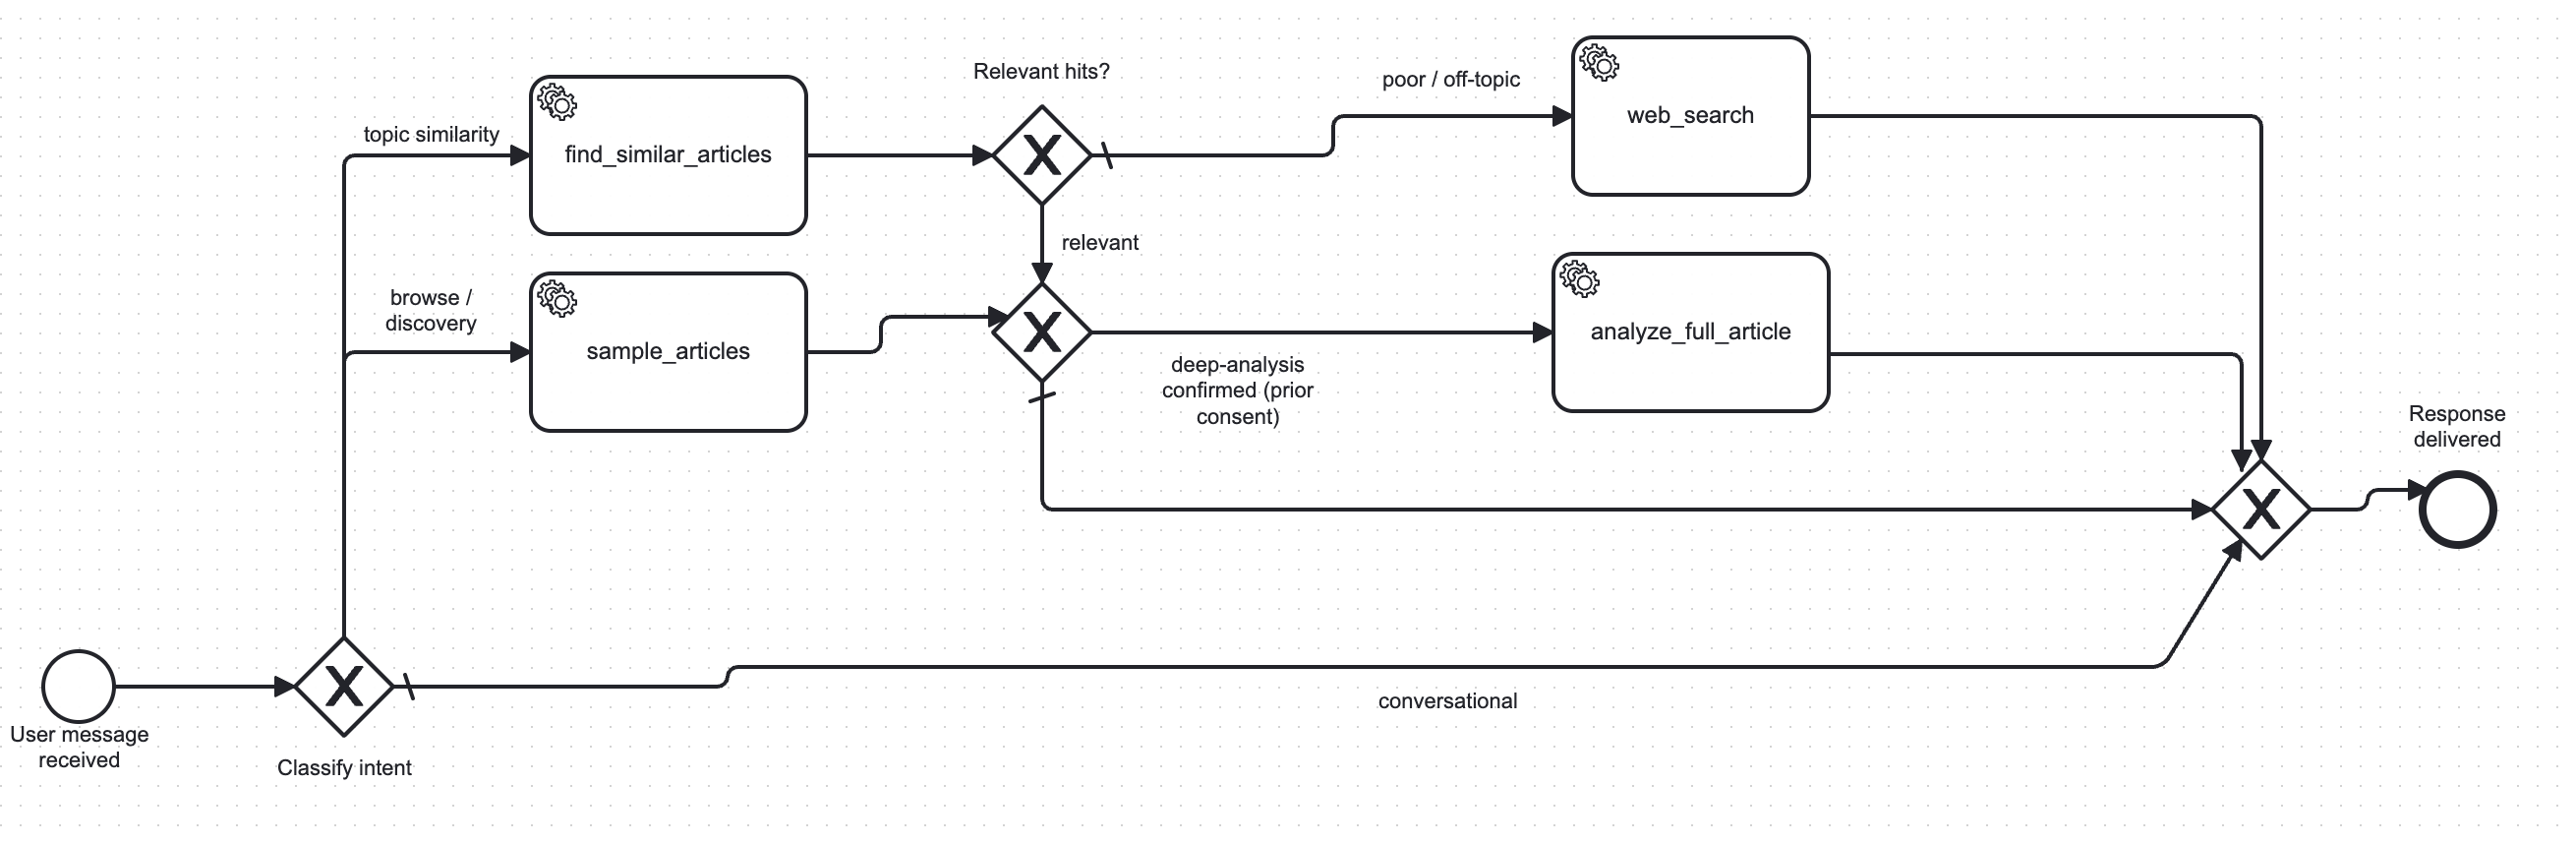


When invoked, the agent classifies intent. It is one of the following:

- A RAG search, such as "find me articles about process mining". In this case the process executing the find_similar_articles tool
- An article browse like "show me 3 artticles". In this case the process executing the sample_articles tool.
- Something else: either a request not supported by this agent or a question to be answered from existing context. This leads to the end of the process.

When the RAG search fails to find suitable articles, the flow calls web_search tool to find articles from the arXiv website (or other sites if applicable). 

In the above tools the user gets a summary view of the article: title, abstract, authors, and article metadata. The user may also ask for a full analysis of the entire article via the analyze_full_article tool. This is expensive, so the process waits for the user to confirm they want to do it.

## Event Log Summary
We ingest the XES trace that we converted from XRay. We have two events logs. One is trace-based: each invocation of the agent is treated as a case. The other is session-based: the overall session is treated as a case. 

It's hard to decide up front whether trace or session is a better scope for a case. We expect the trace-based log will conform better to the process mode. But we are also interested to see the process shape of conversational research session.

The start and end events are trace- and session-based event are wide open. Every known activity types is seen here.

In [1]:
import pm4py
import pmagent_util
from pm4py.objects.bpmn.importer import importer as bpmn_importer
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments

log_xes_session = pm4py.read_xes('xeslogs/research_agent_react_DEFAULT_session.xes', return_legacy_log_object=True)
log_xes_trace = pm4py.read_xes('xeslogs/research_agent_react_DEFAULT_trace.xes', return_legacy_log_object=True)

[ "session", "start", pm4py.get_start_activities(log_xes_session), "end",  pm4py.get_end_activities(log_xes_session) ,
  "trace", "start", pm4py.get_start_activities(log_xes_trace), "end",  pm4py.get_end_activities(log_xes_trace) 
]

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/25 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/65 [00:00<?, ?it/s]

['session',
 'start',
 {'find_similar_articles': 12, 'sample_articles': 13},
 'end',
 {'find_similar_articles': 10, 'analyze_full_article': 9, 'web_search': 6},
 'trace',
 'start',
 {'find_similar_articles': 29,
  'sample_articles': 27,
  'analyze_full_article': 9},
 'end',
 {'find_similar_articles': 39,
  'web_search': 6,
  'analyze_full_article': 9,
  'sample_articles': 11}]

## Bring into data frame

pm4py uses Pandas data frames. Let's load our XES log into one and look at the frame.
We show a sample of the trace frame.

In [2]:
df_session = pm4py.convert_to_dataframe(log_xes_session)
df_trace  = pm4py.convert_to_dataframe(log_xes_trace)
df_trace

,concept:name,org:resource,time:timestamp,duration_s,trace_id,session_id,case:concept:name
0,find_similar_articles,joecool,2026-05-19 20:41:59.917000+00:00,0.601,d0b8273595802a06,d0551293-7686-4eff-878f-fb47252799d8,d0b8273595802a06
1,find_similar_articles,joecool,2026-05-19 20:45:03.012000+00:00,0.360,cf318f4792d47f52,592ee597-8218-45c4-88d8-03006dd8c5f2,cf318f4792d47f52
2,sample_articles,joecool,2026-05-19 20:44:37.951000+00:00,0.173,4ad58d0c20083fa6,592ee597-8218-45c4-88d8-03006dd8c5f2,4ad58d0c20083fa6
3,find_similar_articles,joecool,2026-05-19 20:44:41.561000+00:00,0.433,4ad58d0c20083fa6,592ee597-8218-45c4-88d8-03006dd8c5f2,4ad58d0c20083fa6
4,find_similar_articles,joecool,2026-05-19 20:49:36.440000+00:00,0.469,20e88b2c455ceff2,e19be4f9-28c8-4e1c-ad34-3dc4f9bcf0fc,20e88b2c455ceff2
...,...,...,...,...,...,...,...
113,find_similar_articles,joecool,2026-05-20 19:58:08.445000+00:00,0.450,71895dc1729c7e48,8005cad4-7923-42d0-9334-fd8f780ff5c1,71895dc1729c7e48
114,find_similar_articles,joecool,2026-05-20 19:58:13.646000+00:00,0.409,71895dc1729c7e48,8005cad4-7923-42d0-9334-fd8f780ff5c1,71895dc1729c7e48
115,web_search,joecool,2026-05-20 19:58:18.063000+00:00,0.174,71895dc1729c7e48,8005cad4-7923-42d0-9334-fd8f780ff5c1,71895dc1729c7e48
116,sample_articles,joecool,2026-05-20 19:59:33.952000+00:00,0.060,b4c7720545e2519f,ec3ec2ac-9aed-4160-a949-431147479f6a,b4c7720545e2519f


We see which activities occur most frequently. Not surprising find_similar_articles, a RAG search, is most common.

In [3]:
["session" , df_session["concept:name"].value_counts(), 
 "trace", df_trace["concept:name"].value_counts() ]

['session',
 concept:name
 find_similar_articles    76
 sample_articles          27
 analyze_full_article      9
 web_search                6
 Name: count, dtype: int64,
 'trace',
 concept:name
 find_similar_articles    76
 sample_articles          27
 analyze_full_article      9
 web_search                6
 Name: count, dtype: int64]

We suspect the analyze_full_article activity is the most expensive. This chart shows its execution duration compared to the other activities.

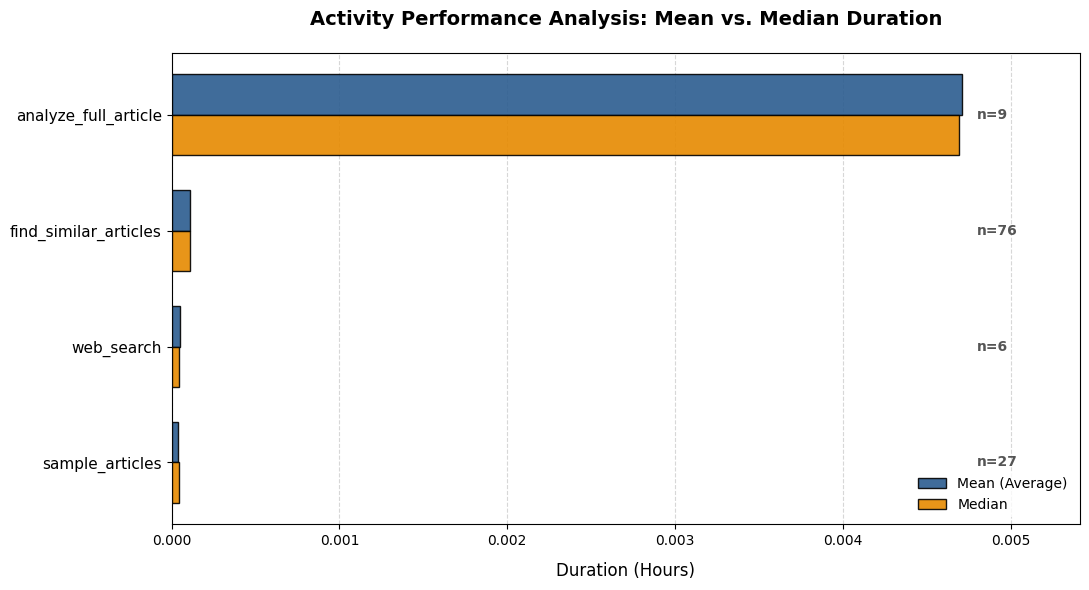

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run the aggregation (converting raw seconds to hours)
performance_df = df_trace.groupby('concept:name').agg(
    avg_hours=('duration_s', lambda x: x.mean() / 3600),
    median_hours=('duration_s', lambda x: x.median() / 3600),
    total_cases=('duration_s', 'count')
).reset_index()

# 3. Sort ascending so the longest running activity appears at the top of the chart
performance_df = performance_df.sort_values(by='avg_hours', ascending=True)

# 4. Initialize layout
plt.figure(figsize=(11, 6))
plt.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)

y_positions = np.arange(len(performance_df))
bar_width = 0.35

# 5. Plot the grouped horizontal bars (Mean vs Median)
plt.barh(
    y_positions + bar_width/2, performance_df['avg_hours'], 
    height=bar_width, label='Mean (Average)', 
    color='#2b5c8f', edgecolor='black', alpha=0.9, zorder=3
)

plt.barh(
    y_positions - bar_width/2, performance_df['median_hours'], 
    height=bar_width, label='Median', 
    color='#e68a00', edgecolor='black', alpha=0.9, zorder=3
)

# 6. Formatting titles and labels
plt.yticks(y_positions, performance_df['concept:name'], fontsize=11)
plt.xlabel('Duration (Hours)', fontsize=12, labelpad=10)
plt.title('Activity Performance Analysis: Mean vs. Median Duration', fontsize=14, pad=20, weight='bold')
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')

# 7. Dynamic right margin annotation to show total execution counts (n=...)
max_value = max(performance_df['avg_hours'].max(), performance_df['median_hours'].max())
for idx, count in enumerate(performance_df['total_cases']):
    plt.text(
        max_value * 1.02, idx, f"n={count:}", 
        va='center', ha='left', fontsize=10, color='#555555', weight='bold'
    )

plt.xlim(0, max_value * 1.15) # Dynamically allocates spacing for annotations
plt.tight_layout()

# Display or save
plt.show()

How many total cases do we have? What are the most common variants (or tool paths taken) in these cases? 

We look at this for both traces and sessions. There is a lot of stutter (e.g,, find_similar_articles repeating itself). If we clean up the stutter, we see a more manageable list of variants.


In [5]:
trace_variants=pm4py.get_variants(df_trace, activity_key="concept:name", case_id_key="case:concept:name")
print("\n**Trace variants")
pmagent_util.dump_variants(df_trace,trace_variants)

session_variants=pm4py.get_variants(df_session, activity_key="concept:name", case_id_key="case:concept:name")
print("\n**Session variants")
pmagent_util.dump_variants(df_session,session_variants)



**Trace variants
Number of cases 65

Frequent variants
15 find_similar_articles
12 sample_articles->find_similar_articles
11 sample_articles
9 analyze_full_article

All variants
15 find_similar_articles
12 sample_articles->find_similar_articles
11 sample_articles
9 analyze_full_article
5 find_similar_articles->find_similar_articles
3 find_similar_articles->find_similar_articles->find_similar_articles
3 sample_articles->find_similar_articles->find_similar_articles->find_similar_articles
3 find_similar_articles->find_similar_articles->find_similar_articles->web_search
2 find_similar_articles->find_similar_articles->web_search
1 find_similar_articles->web_search
1 sample_articles->find_similar_articles->find_similar_articles->find_similar_articles->find_similar_articles->find_similar_articles->find_similar_articles->find_similar_articles

All variants, stutter removed
23 find_similar_articles
16 sample_articles->find_similar_articles
11 sample_articles
9 analyze_full_article
6 find_simil

Let's clean the two data frames to remove this stutter

In [6]:
df_trace = pmagent_util.deduplicate_agent_stutter(df_trace)
df_session = pmagent_util.deduplicate_agent_stutter(df_session)


--- Data Cleaning Metrics ---
Original Event Count: 118
Cleaned Event Count:  87
Dropped Stutter Rows: 31 (26.27%)
--- Data Cleaning Metrics ---
Original Event Count: 118
Cleaned Event Count:  81
Dropped Stutter Rows: 37 (31.36%)


## Discovery

From the event log, discover the process. For comparison, bring in our intended model so it can be compared. Recall, we drew our intended model (shown above) as a BPMN process using bpmn.io open-source editor.

To discover the process, we use the inductive miner. The Inductive Miner uses a top-down, divide-and-conquer approach that recursively breaks the event log down into standard workflow structures: sequences, loops, exclusive-or (XOR) choices, and parallel paths. By default, it guarantees a mathematically sound model that fits all the cases in the log. However, to achieve this perfect fitness, it tends to overgeneralize, meaning it can create a model that is highly structured but occasionally too permissive. Fortunately, the algorithm can be configured to filter out infrequent variants and tolerate noise.

We visualize three BPMN models: our intended model, the inductively discovered model at the trace level, and the inductively discovered model at the session level. The result is somewhat chaotic.

The Trace Model permits analyze_full_article to execute right at the beginning. It completely reverses our intended logic by executing sample_articles before find_similar_articles, while flattening these core tools into strict, mutually exclusive alternatives.

The Session Model similarly forces sample_articles to run before find_similar_articles and treats them as alternatives, but traps the entire discovery phase in a repetitive execution loop.

The Architectural Flaw: Crucially, both models completely de-couple web_search and analyze_full_article from find_similar_articles. Instead of acting as a prerequisite gatekeeper to guide search and analysis, discovery is running completely independent of them.



Intended model


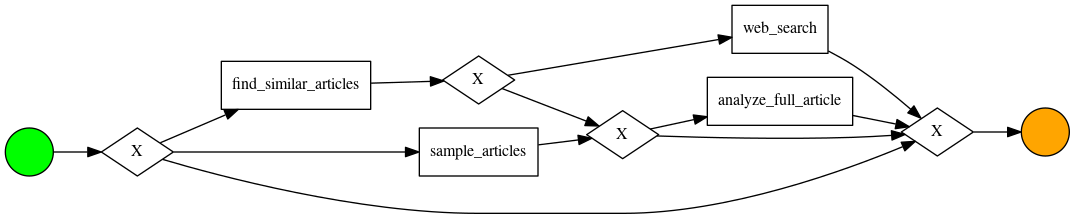

Discovered model - trace


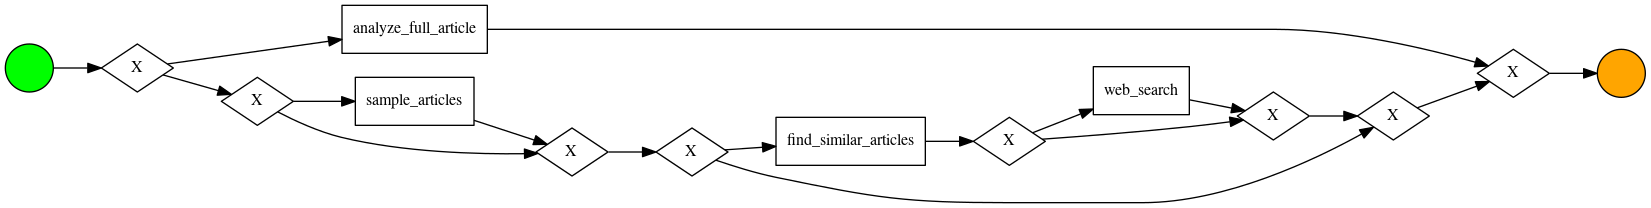

Discovered model - session


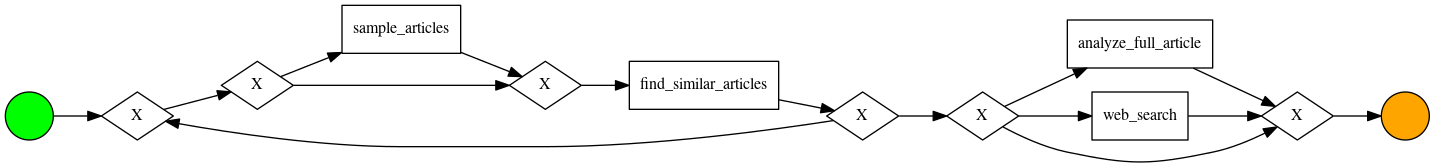

In [9]:
intended_bpmn_model = bpmn_importer.apply("../agents/research_react/intended_flow.bpmn")
tr_discovered_bpmn_model = pm4py.discover_bpmn_inductive(df_trace)
s_discovered_bpmn_model = pm4py.discover_bpmn_inductive(df_session)

print("Intended model")
pm4py.view_bpmn(intended_bpmn_model)
print("Discovered model - trace")
pm4py.view_bpmn(tr_discovered_bpmn_model)
print("Discovered model - session")
pm4py.view_bpmn(s_discovered_bpmn_model)

Maybe there is still too much noise.

Let's try running the inductive miner with a noise reduction parameter.

We also run the Heuristic Miner. The Inductive Miner uses a top-down approach that forces raw event logs into strict, mathematically sound structural blocks, which guarantees no deadlocks but often sacrifices precision by overgeneralizing allowable paths. In contrast, the Heuristic Miner takes a pragmatic, statistical approach based on frequency thresholds and activity dependencies, making it vastly superior at filtering out real-world noise and preserving precise agent paths. However, because the Heuristic Miner maps local dependencies instead of rigid global blocks, it does not guarantee a mathematically sound model, presenting a direct trade-off between structural perfection and practical diagnostic clarity.

We test using only the trace log and do not see enough of an improvement. The noise-reduced inductive model still compares poorly to the inteded model. The heuristic model filters out the analyze_full_article but does not sort out the choice between find_similar_articles and sample_articles. 

Discovered model - less noise


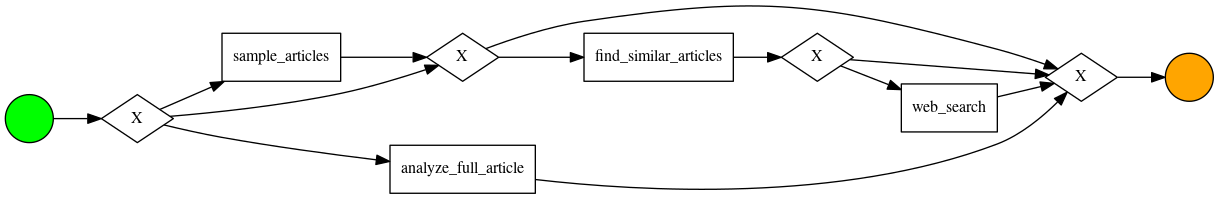

Discovered noise - heuristic


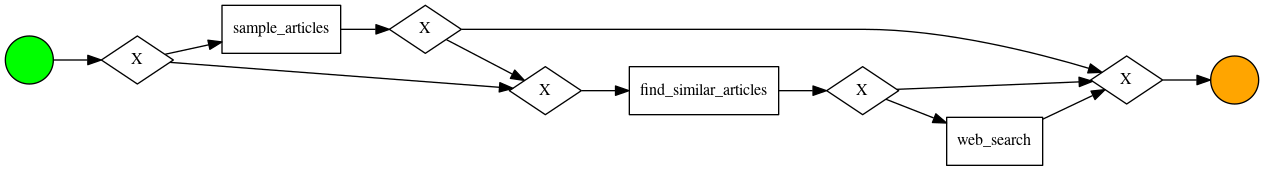

In [10]:
less_noise_param=0.8
disc_pn_ind_quiet_net, disc_pn_ind_quiet_im, disc_pn_ind_quiet_fm  = pm4py.discover_petri_net_inductive(df_trace, less_noise_param)
disc_pn_heu_net, disc_pn_heu_im, disc_pn_heu_fm  = pm4py.discover_petri_net_heuristics(df_trace)

print("Discovered model - less noise")
#pm4py.view_petri_net(disc_pn_ind_quiet_net, disc_pn_ind_quiet_im, disc_pn_ind_quiet_fm)
pm4py.view_bpmn(pm4py.convert_to_bpmn(disc_pn_ind_quiet_net, disc_pn_ind_quiet_im, disc_pn_ind_quiet_fm))
print("Discovered noise - heuristic")
#pm4py.view_petri_net(disc_pn_heu_net, disc_pn_heu_im, disc_pn_heu_fm)
pm4py.view_bpmn(pm4py.convert_to_bpmn(disc_pn_heu_net, disc_pn_heu_im, disc_pn_heu_fm))

There are many other discovery options. See MarketIntel and Trusteeship process analysis notebooks for a presentation of the main approaches. Given the discovery difficulties with this model, the most promising visualization is a heuristic net. It has several advantages:

- It shows *directly follows* relationships between activities. That is, it shows which activity follows which activity.
- It also deals with noise and avoids rendering a spaghetti view in which nearly every variant is possible.
- It shows frequencies, which helps us sort out the most frequent occurrences of one activity following another.

The distinct power of a Heuristic Net is that it takes *directly follows* relationships and filters them through a dependency matrix to isolate true causality from random sequential noise.

We will render it at the trace level and the session level. Our goal:

- Confirm at trace level, we see sequences of activities aligned with the ReAct design.
- Try to discover a trend at the session level. This part is speculative because research is ad hoc in nature.

The trace level net is the most favorable view yet! An agent invocation tends to start with either sample_articles or find_similar_articles. These are the main article finders. Sometimes sample_articles is followed by find_similar_articles for questions where the agents needs multiple tools like "Give me N articles pertainiing for T". We see that web_search follows find_similar_articles, as expected. We don't see summarize_full_article. removed because of noise reduction.

The trace-level net structurally agrees with the high-level heuristic process model discovered previously. But the raw frequencies here provide the definitive empirical validation that the agent's core execution loop is stable and well-behaved.

The session level net is messy. It does confirm that, over the course of a converational session, many sample_articles and find_similar_articles will be used. Further, when web_search and analyze_full_article tools are called, they generally follow find_similar_articles.


Heuristic net - trace level


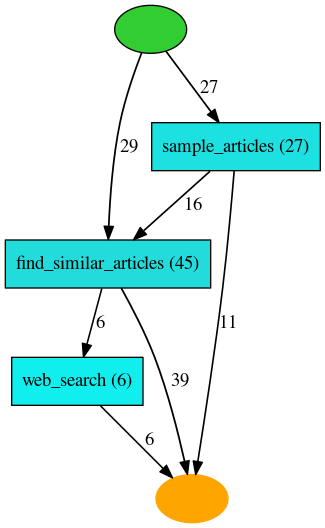

Heuristic net - session level


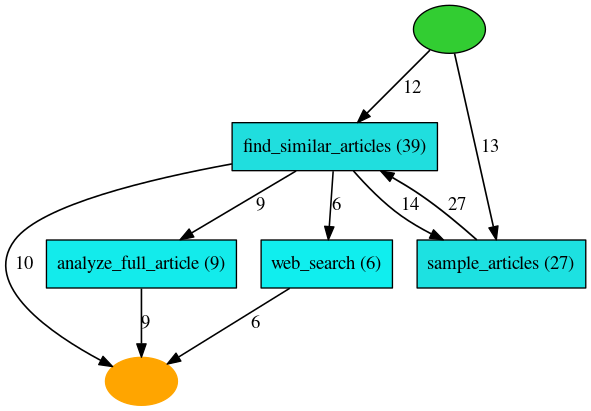

In [11]:
tr_hnet=pm4py.discover_heuristics_net(df_trace)
print("Heuristic net - trace level")
pm4py.view_heuristics_net(tr_hnet)

s_hnet=pm4py.discover_heuristics_net(df_session)
print("Heuristic net - session level")
pm4py.view_heuristics_net(s_hnet)


## Conformance

Now we use pm4py conformance tools to assess how well the event log aligns with our intended model. We compare that to the discovered model (specifically the inducitve model). 

Because session-level is so ad-hoc, we'll focus on trace level. 

We will use token-based replay to measure conformance. Token-based replay uses an execution audit that replays the event log traces through the process step-by-step. Token-based replay tracks compliance by counting "tokens" that are correctly consumed, missing (required but unavailable), or stranded (left over at execution end).

- *Fitness* is the degree to which the event log traces can be successfully replayed by the model. High fitness means the architecture successfully accounts for all the tool paths and edge cases the agent actually executed in production.
- *Precision* is the degree to which the model restricts behavior not seen in the log. High precision means the architecture tightly constrains the agent, preventing it from wandering into unprescribed tool loops or "off-road" states that never occurred in reality.
  
We also visualize issues caught during conformance.

What we see is encouraging. 

- The intended model has more than 61 percent fitness, higher than we expected after looking at the discovered process model. About 6 in 10 cases fit the intended model. Even better, the log fitness of 91.8 percent is very high, meaning those cases that did not fit were not catastrophic pipeline collapses. The agent didn't completely break down or skip the entire process. The token replay engine only had to artificially inject or strand a small handful of tokens to force the logs through your intended model.
- The discovered model has 100 percent fitness, to be expected because the inductive miner produces a model that fits all the cases.
- Both intended and discovered models are precise. Surprisingly the intended model's precision is lower, at 86 percent. It allows for about 14% "underutilized capability"—theoretical paths, alternative loops, or bypasses that you hardcoded into the architecture but your agent never actually chose to travel down during this test run.

In [14]:
intended_pn_net, intended_pn_im, intended_pn_fm = pm4py.convert_to_petri_net(intended_bpmn_model)
disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm = pm4py.convert_to_petri_net(tr_discovered_bpmn_model)

for s in [ 
    "\nintended fitness (token-based replay)", 
    pm4py.fitness_token_based_replay(df_trace, intended_pn_net,intended_pn_im,intended_pn_fm),
    "\ndiscovered fitness (token-based replay)",
    pm4py.fitness_token_based_replay(df_trace, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm ),
    "\nintended precision (token-based replay)",
    pm4py.precision_token_based_replay(df_trace, intended_pn_net,intended_pn_im,intended_pn_fm),
    "\ndiscovered precision (token-based replay)",
    pm4py.precision_token_based_replay(df_trace, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm )
]:
    print(s)

replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]


intended fitness (token-based replay)
{'perc_fit_traces': 61.53846153846154, 'average_trace_fitness': 0.9186813186813187, 'log_fitness': 0.9368686868686869, 'percentage_of_fitting_traces': 61.53846153846154}

discovered fitness (token-based replay)
{'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}

intended precision (token-based replay)
0.8607594936708861

discovered precision (token-based replay)
1.0


Let's diagnose the token-based replay

In [16]:
tbr_results = pm4py.conformance_diagnostics_token_based_replay(df_trace, intended_pn_net,intended_pn_im,intended_pn_fm)
pmagent_util.dump_conformance_diagnostics(df_trace, tbr_results, "token")

replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

=== NON-COMPLIANT AGENT TRACE AUDIT (TOKEN METHOD) ===
Found 2 distinct non-compliance patterns:

⚠️  Pattern Detected: 16 occurrences
   Impacted Case IDs: [170eed03111c9cf3, 2207f51aa7deb27e, 4ad58d0c20083fa6 ... (+13 more)]
   Discovered Variant: sample_articles->find_similar_articles
   Compliance Issue: The agent broke sequence rules. It attempted to execute 
                     'find_similar_articles' before prerequisite phase gates opened/closed.
   Replay Metrics:     Missing Tokens: 1 | Stranded Tokens: 1

--------------------------------------------------------------------------------

⚠️  Pattern Detected: 9 occurrences
   Impacted Case IDs: [411781cd3c53029b, 4c57b2787d279010, 818cb692775b3e49 ... (+6 more)]
   Discovered Variant: analyze_full_article
   Compliance Issue: The agent broke sequence rules. It attempted to execute 
                     'analyze_full_article' before prerequisite phase gates opened/closed.
   Replay Metrics:     Missing Tokens: 1 | Stranded Toke

## Findings and Recommendations

Analyzing the event log was fruitful:

- We saw how relatively expensive the analyze_full_article tool is.
- We found lots of stutter, or repeating activities among the process variants. We expected this and were happy to clear the log of stutter for better mining analysis.

We ran process discovery on both trace-level and session-level logs. Session-level discovery revealed what we should have expected: a conversational research process is ad-hoc and does NOT have a well-defined process flow. 

For trace level, we used the Inductive Miner to discover a process that seemed at odds with our intended model. We then used the Heuristic Miner and compared BPMN and Heuristic Net representations. The Heuristic Net's frequencies gave us the empirical evidence that the agent generally executes as our ReAct design intends. First encouraging news of the notebook.

Next, we ran a conformance check against both our intended model and the inductively discovered model. Trace-level ONLY! We found surprising high fitness in our intended model. Cases that violated the intended model included these:

- sample_articles->find_similar_articles
- analyze_full_article

These variants are reasonable. There is no need to go back and change our agent! Actually, the model fails to capture all the essential paths. *sample_articles->find_similar_articles* is just the agent combining its two search tools when the question requires a combination of tools. *analyze_full_article* is expected when the user is asked to confirm whether to go ahead with an expensive full analysis.

The main recommendations are:

- Seeing how expensive analyze_full_article is, continue requiring the user's go-ahead before using it.
- Observe overall agent performance, including token counts. If it gets very high relative to the number of requests, take another look at how much stutter is happening. Maybe revise the system prompt to reduce wasteful tool invocations. But for now, no issues here!
